In [18]:
# 0. Extra (Zaroori): Train/Test Split + Metrics
# ML mein model ko wohi data dobara test ke liye nahi
# dete jis pe train kiya. Data ko 2 hisson mein todte hain.

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes

data = load_diabetes()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (353, 10) Test: (89, 10)


In [19]:
# 94 – What is Machine Learning?
from sklearn.linear_model import LinearRegression

X = [[500], [800], [1000], [1200], [1500]]   # size (sq ft)
y = [25, 40, 50, 60, 75]                     # price (lakh)

model = LinearRegression()
model.fit(X, y)                 # seekho
print(model.predict([[1100]]))  # andaza lagao

[55.]


In [20]:
# 95–98 – Linear Regression: Math, Cost Function, MSE
import numpy as np

X = np.array([1, 2, 3, 4, 5])
y = np.array([3, 5, 7, 9, 11])     # asli rule: y = 2x + 1

def predict(X, m, b):
    return m * X + b

def mse(y, y_pred):
    return np.mean((y - y_pred) ** 2)

# Do alag guesses ka cost compare karo
print("Bura guess (m=1, b=0):", mse(y, predict(X, 1, 0)))
print("Sahi guess (m=2, b=1):", mse(y, predict(X, 2, 1)))   # 0.0 aayega

Bura guess (m=1, b=0): 18.0
Sahi guess (m=2, b=1): 0.0


m = 2.0 b = 1.0


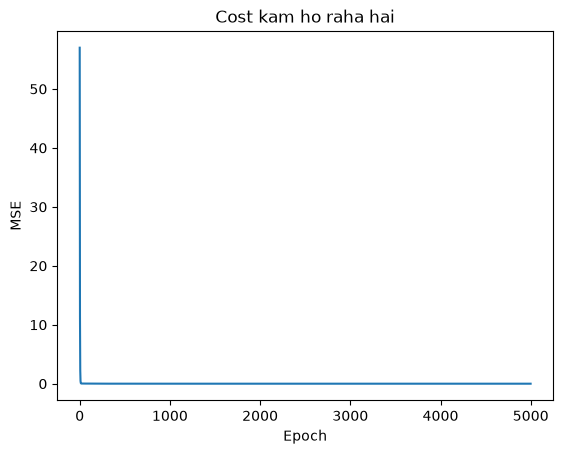

In [21]:

# 99–101 – Gradient Descent + Linear Regression from Scratch
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([3, 5, 7, 9, 11], dtype=float)

m, b = 0.0, 0.0        # shuru mein random/zero
lr = 0.01              # learning rate
epochs = 5000
n = len(X)
history = []

for i in range(epochs):
    y_pred = m * X + b
    error = y - y_pred

    # gradients (MSE ka derivative)
    dm = (-2 / n) * np.sum(X * error)
    db = (-2 / n) * np.sum(error)

    # update
    m = m - lr * dm
    b = b - lr * db

    history.append(np.mean(error ** 2))

print("m =", round(m, 3), "b =", round(b, 3))   # ~2 aur ~1

plt.plot(history)
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("Cost kam ho raha hai")
plt.show()

In [22]:
# 102 – Linear Regression with Scikit-Learn (Proper Way)
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 :", r2_score(y_test, y_pred))
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

MSE: 2900.193628493482
R2 : 0.45260276297191937
Coefficients: [  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
Intercept: 151.34560453985995


In [5]:
# 103 – Introduction to Decision Trees
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_text

iris = load_iris()
X, y = iris.data, iris.target

tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X, y)

# Tree ke rules text mein dekho
print(export_text(tree, feature_names=iris.feature_names))

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.75
|   |   |--- class: 1
|   |--- petal width (cm) >  1.75
|   |   |--- class: 2



Accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


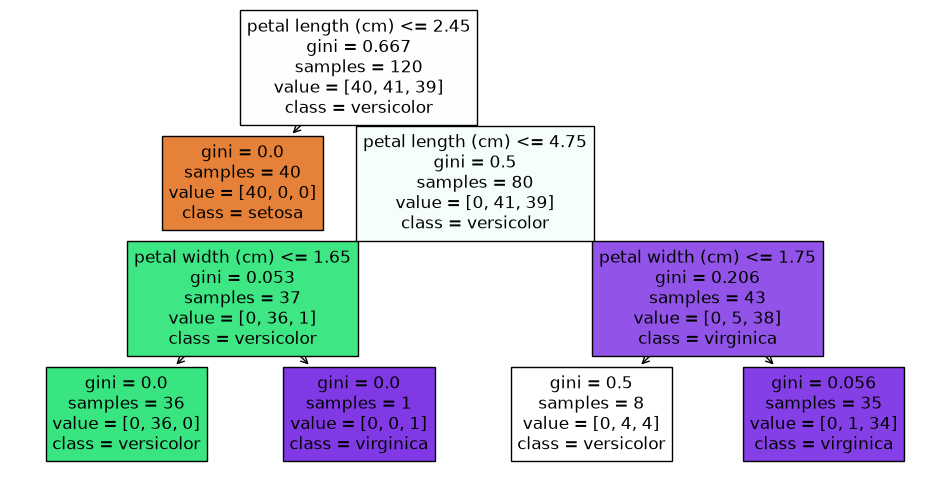

In [6]:
# 108 – Decision Tree Implementation (Full)

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

plt.figure(figsize=(12, 6))
plot_tree(model, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True)
plt.show()